# Problem C: Surrogate Modeling for Steady-State Heat Conduction in Heterogeneous Materials

Consider the steady-state heat conduction problem in a heterogeneous solid material occupying the unit square domain $\Omega = [0,1]^2$:

$$
\begin{split}
-\nabla\cdot(a(x,y)\nabla u) &= f,\quad (x,y)\in\Omega=[0,1]^2 \\
u &= 0,\quad (x,y)\in\partial\Omega
\end{split} \tag{2}
$$

where $u(x,y)$ denotes the temperature field, $a(x,y) > 0$ denotes the spatially varying thermal conductivity of the material, and the uniform heat source is given by $f = 10$. The zero Dirichlet boundary condition models a configuration in which the boundary of the domain is kept at a fixed reference temperature.

In computational materials science, evaluating the thermal response of a large number of candidate microstructures is a central bottleneck in material screening and design workflows. Although high-fidelity Finite Element Method (FEM) solvers can produce accurate solutions, they are computationally expensive when applied repeatedly to thousands of different conductivity fields $a(x,y)$.

## Task: Learning the Solution Operator $a(x,y) \mapsto u(x,y)$

The goal of this task is to make a fast prediction of the temperature field $u(x,y)$ given $a(x,y)$. To this end, a dataset of input-output pairs $\{a^{(j)}, u^{(j)}\}$ has been pre-computed using a high-precision FEM solver. The conductivity fields $a^{(j)}$ are sampled from a distribution $\mathcal{A}$ over spatially heterogeneous functions, representative of realistic microstructural variability in composite materials. Once trained, the model should accurately predict the temperature field for new, unseen conductivity samples drawn from the same distribution $\mathcal{A}$, at a fraction of the cost of a full FEM solve.

### Goals

- Please select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The $L^2$ relative error between predictions $\{u^{(j)}_{\text{pred}}\}_{j=1}^{N}$ and ground truth $\{u^{(j)}_{\text{true}}\}_{j=1}^{N}$ is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\sum_i\left|u^{(j)}_{\text{pred}}(x_i)-u^{(j)}_{\text{true}}(x_i)\right|^2}{\sum_i\left|u^{(j)}_{\text{true}}(x_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatial grid point.

- For the **first test instance**, use `matplotlib` to plot the following in separate figures:
  1. The input conductivity field $a(x,y)$
  2. The predicted temperature field $u_{\text{pred}}(x,y)$
  3. The ground truth temperature field $u_{\text{true}}(x,y)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

The training and test data are provided in `ProblemC_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train` | (1000, 128, 128) | Training conductivity fields sampled from $\mathcal{A}$ |
| `u_train` | (1000, 128, 128) | Corresponding FEM-computed temperature fields (training) |
| `a_test` | (200, 128, 128) | Test conductivity fields (for error evaluation only, **do not use for training**) |
| `u_test` | (200, 128, 128) | Corresponding FEM-computed temperature fields (test reference, **do not use for training**) |
| `X` | (128, 128) | $x$-coordinates of the $128\times 128$ regular spatial grid |
| `Y` | (128, 128) | $y$-coordinates of the $128\times 128$ regular spatial grid |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['X', 'Y', 'a_test', 'a_train', 'u_test', 'u_train']>
The shape of X: torch.Size([128, 128]) The shape of Y: torch.Size([128, 128])
The shape of a_train: torch.Size([1000, 128, 128])
The shape of u_train: torch.Size([1000, 128, 128])
The shape of a_test: torch.Size([200, 128, 128])
The shape of u_test: torch.Size([200, 128, 128])


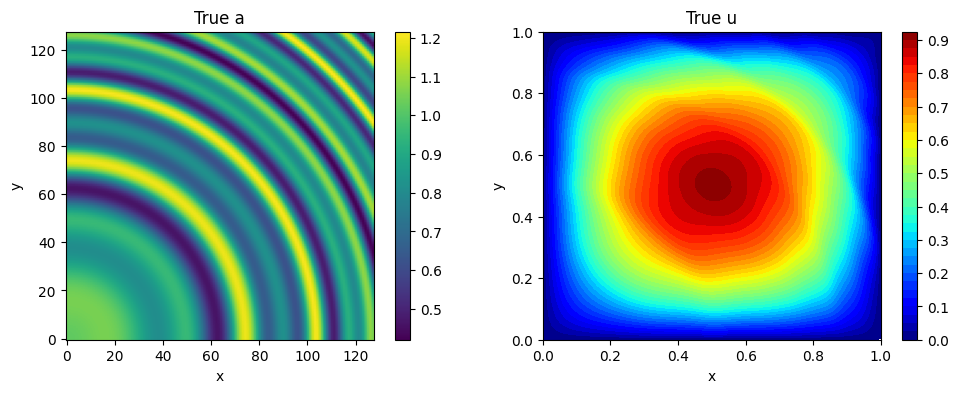

In [1]:
import numpy as np
import h5py
import torch 
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
device = 'cpu'
dtype = torch.float32
######################################
# Load training data
######################################
with h5py.File('Datasets/ProblemC_dataset.h5', 'r') as data:
    print(data.keys())
    a_train = torch.tensor(np.array(data["a_train"]), dtype=dtype)
    u_train = torch.tensor(np.array(data["u_train"]), dtype=dtype)
    a_test = torch.tensor(np.array(data["a_test"]), dtype=dtype)
    u_test =torch.tensor( np.array(data["u_test"]), dtype=dtype)
    # The coordinates
    X = torch.tensor(np.array(data['X']), dtype=dtype)
    Y = torch.tensor(np.array(data['Y']), dtype=dtype)
print('The shape of X:', X.shape, 'The shape of Y:', Y.shape)
print('The shape of a_train:', a_train.shape)
print('The shape of u_train:', u_train.shape)
print('The shape of a_test:', a_test.shape)
print('The shape of u_test:', u_test.shape)

####### Visualize the training data 
a_show, u_show = a_train[1], u_train[1]
#
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
#
cntr0 = axs.flat[:][0].imshow(a_show, origin='lower')
fig.colorbar(cntr0, ax=axs.flat[:][0])
axs.flat[:][0].set_title('True a')
axs.flat[:][0].set_xlabel('x')
axs.flat[:][0].set_ylabel('y')
#
cntr1 = axs.flat[:][1].contourf(X, Y, u_show, levels=40, cmap='jet')
fig.colorbar(cntr1, ax=axs.flat[:][1])
axs.flat[:][1].set_title('True u')
axs.flat[:][1].set_xlabel('x')
axs.flat[:][1].set_ylabel('y')
#
plt.show()

### Additional Imports and Device Setup

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader

from tqdm import trange
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Use CUDA if available, else use CPU
dataType = torch.float32    # sets the PyTorch tensor type to 32-bit floating point

np.random.seed(1234)    # fixes NumPy’s random seed, reproducible result
torch.manual_seed(1234) # fixes PyTorch’s random seed, reproducible result

print(f"device: {device}")

device: cuda


### FNO input data preparation

In [3]:
# --- Convert numpy arrays to torch tensors ---
a_train_t = torch.tensor(a_train, dtype=dataType)
u_train_t = torch.tensor(u_train, dtype=dataType)

a_test_t = torch.tensor(a_test, dtype=dataType)
u_test_t = torch.tensor(u_test, dtype=dataType)

X_t = torch.tensor(X, dtype=dataType)
Y_t = torch.tensor(Y, dtype=dataType)

# Add one channel dimension to a and u
a_train_t = a_train_t.unsqueeze(-1)
u_train_t = u_train_t.unsqueeze(-1)

a_test_t = a_test_t.unsqueeze(-1)
u_test_t = u_test_t.unsqueeze(-1)

# Repeat coordinate grids for all samples
X_train = X_t.unsqueeze(0).unsqueeze(-1).repeat(a_train_t.shape[0], 1, 1, 1)
Y_train = Y_t.unsqueeze(0).unsqueeze(-1).repeat(a_train_t.shape[0], 1, 1, 1)

X_test = X_t.unsqueeze(0).unsqueeze(-1).repeat(a_test_t.shape[0], 1, 1, 1)
Y_test = Y_t.unsqueeze(0).unsqueeze(-1).repeat(a_test_t.shape[0], 1, 1, 1)

# Concatenate conductivity and coordinates as FNO input
# Input channels: [a, X, Y]
ax_train = torch.cat([a_train_t, X_train, Y_train], dim=-1)
ax_test = torch.cat([a_test_t, X_test, Y_test], dim=-1)

# --- prints ---
print("ax_train shape:", ax_train.shape)
print("u_train shape:", u_train_t.shape)
print("ax_test shape:", ax_test.shape)
print("u_test shape:", u_test_t.shape)

ax_train shape: torch.Size([1000, 128, 128, 3])
u_train shape: torch.Size([1000, 128, 128, 1])
ax_test shape: torch.Size([200, 128, 128, 3])
u_test shape: torch.Size([200, 128, 128, 1])


C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_18112\1633770962.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a_train_t = torch.tensor(a_train, dtype=dataType)
C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_18112\1633770962.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_train_t = torch.tensor(u_train, dtype=dataType)
C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_18112\1633770962.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a_test_t = torch.tensor(a_test, dtype=dataType)
C:\Users\Man

### The FNO architecture

In [4]:
# Spectral Convolution layer - 2d

class SpectralConv2d(torch.nn.Module):
    
    def __init__(self, in_size, out_size, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        Inputs:
            in_size: number of input channels
            out_size: number of output channels
            modes1: number of Fourier modes kept in x-direction
            modes2: number of Fourier modes kept in y-direction
        """

        self.in_size = in_size
        self.out_size = out_size
        self.modes1 = modes1
        self.modes2 = modes2

        # Scaling factor
        self.scale = 1 / (in_size * out_size)

        # Learnable complex weights
        self.weights1 = torch.nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = torch.nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        """
        Complex multiplication
        """
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        """
        Forward pass of the spectral convolution.
        """

        batchsize = x.shape[0]

        # Compute Fourier coefficients (transformation to fourier space)
        x_ft = torch.fft.rfft2(x)

        # Allocate output tensor in Fourier space
        out_ft = torch.zeros(batchsize, self.out_size, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)

        # Multiply selected low-frequency Fourier modes
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        # Transform back to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x

In [5]:
# Fourier Neural Operator (FNO) - 2d

class FNO2d(torch.nn.Module):
    
    def __init__(self, modes1, modes2, width, in_size=3, out_size=1):
        super(FNO2d, self).__init__()

        """
        Inputs:
            modes1: number of Fourier modes kept in x-direction
            modes2: number of Fourier modes kept in y-direction
            width: number of hidden channels
            in_size: number of input channels for Problem C: [a, X, Y] -> 3
            out_size: number of output channels for Problem C: [u] -> 1
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width

        # Lift input channels to hidden channels
        self.fc_in = torch.nn.Linear(in_size, width)

        # Fourier convolution layers
        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)

        # Pointwise 1x1 convolution layers
        self.w0 = torch.nn.Conv2d(width, width, 1)
        self.w1 = torch.nn.Conv2d(width, width, 1)
        self.w2 = torch.nn.Conv2d(width, width, 1)
        self.w3 = torch.nn.Conv2d(width, width, 1)

        # Project hidden channels back to output field
        self.fc_out0 = torch.nn.Linear(width, 128)
        self.fc_out1 = torch.nn.Linear(128, out_size)

        self.activation = torch.nn.GELU()

    def forward(self, x):
        """
        Forward pass.
        """

        # Lift input from in_size channels to width channels
        x = self.fc_in(x)

        # Change shape from [batch, nx, ny, width]
        # to [batch, width, nx, ny] for convolution layers
        x = x.permute(0, 3, 1, 2)

        # Fourier layer 1
        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = self.activation(x1 + x2)

        # Fourier layer 2
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = self.activation(x1 + x2)

        # Fourier layer 3
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = self.activation(x1 + x2)

        # Fourier layer 4
        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = self.activation(x1 + x2)

        # Change shape back from [batch, width, nx, ny]
        # to [batch, nx, ny, width]
        x = x.permute(0, 2, 3, 1)

        # Project hidden channels to output u
        x = self.activation(self.fc_out0(x))
        x = self.fc_out1(x)

        return x

### Loss Function

In [6]:
# Normalizer

class UnitGaussianNormalizer():
    
    def __init__(self, ax, eps=1e-8):
        super(UnitGaussianNormalizer, self).__init__()
        
        """
        Unit Gaussian normalizer.

        For ax = [a, X, Y], only the first channel a is normalized.
        For u = [u], the only channel u is normalized.
        """

        # Compute mean and standard deviation over the sample dimension
        self.mean = torch.mean(ax[..., 0:1], dim=0)
        self.std = torch.std(ax[..., 0:1], dim=0)
        self.eps = eps
    
    def encode(self, ax):
        """
        Normalize the first channel.
        For ax = [a, X, Y], this normalizes a and keeps X,Y unchanged.
        """

        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)

        ax = torch.cat([(ax_list[0] - self.mean) / (self.std + self.eps), ax_list[1]], dim=-1)

        return ax
    
    def decode(self, ax):
        """
        Undo the normalization of the first channel.
        """

        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)

        ax = torch.cat([ax_list[0] * (self.std + self.eps) + self.mean, ax_list[1]], dim=-1)

        return ax

# Create normalizers using training data only
normalizer_ax = UnitGaussianNormalizer(ax_train.to(device))
normalizer_u = UnitGaussianNormalizer(u_train_t.to(device))

In [7]:
# Loss function and Relative error (L2)

class LossFNO():
    
    def __init__(self, model_u, normalizer_ax, normalizer_u):
        self.model_u = model_u
        self.normalizer_ax = normalizer_ax
        self.normalizer_u = normalizer_u

    # --- loss term ---
    def loss_data(self, ax, u):

        # Move batch to device
        ax = ax.to(device)
        u = u.to(device)

        # Normalize input and output
        ax_norm = self.normalizer_ax.encode(ax)
        u_norm = self.normalizer_u.encode(u)    # Normalized FEM reference solution

        # Predict normalized temperature field
        u_pred_norm = self.model_u(ax_norm)

        # L2 loss in normalized space
        loss = torch.norm(u_pred_norm.reshape(u_pred_norm.shape[0], -1) - u_norm.reshape(u_norm.shape[0], -1), p=2, dim=1)

        loss = torch.mean(loss)

        return loss

    # --- L2 error ---
    def relative_l2_error(self, ax, u):

        self.model_u.eval()

        with torch.no_grad():
            ax = ax.to(device)
            u = u.to(device)

            # Normalize input
            ax_norm = self.normalizer_ax.encode(ax)

            # Predict normalized output
            u_pred_norm = self.model_u(ax_norm)

            # Decode prediction back to physical scale
            u_pred = self.normalizer_u.decode(u_pred_norm)

            # Relative L2 error per sample
            error = torch.norm(u_pred.reshape(u_pred.shape[0], -1) - u.reshape(u.shape[0], -1), p=2, dim=1) / torch.norm(u.reshape(u.shape[0], -1), p=2, dim=1)

            # Mean relative L2 error over all samples
            error = torch.mean(error)

        self.model_u.train()

        return error.item()

### Training

In [8]:
# Create a Data Loader for Batch Training

class MyDataset(Dataset):

    def __init__(self, ax: torch.tensor, u: torch.tensor):
        self.ax = ax
        self.u = u
    
    def __getitem__(self, index):
        return self.ax[index], self.u[index]

    def __len__(self):
        return self.ax.shape[0]


batch_size = 10

train_loader = DataLoader(MyDataset(ax_train, u_train_t), batch_size=batch_size, shuffle=True)

In [29]:
# Training setup

# FNO hyperparameters
modes1 = 20
modes2 = 20
width = 32

# Training hyperparameters
epochs = 500
learning_rate = 1e-3

model_u = FNO2d(modes1=modes1, modes2=modes2, width=width, in_size=3, out_size=1).to(device)

optimizer = torch.optim.Adam(model_u.parameters(), lr=learning_rate,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

lossClass = LossFNO(model_u=model_u, normalizer_ax=normalizer_ax,normalizer_u=normalizer_u)

# Store training history
loss_train_history = []
l2_test_history = []

print(model_u)

FNO2d(
  (fc_in): Linear(in_features=3, out_features=32, bias=True)
  (conv0): SpectralConv2d()
  (conv1): SpectralConv2d()
  (conv2): SpectralConv2d()
  (conv3): SpectralConv2d()
  (w0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (w1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (w3): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (fc_out0): Linear(in_features=32, out_features=128, bias=True)
  (fc_out1): Linear(in_features=128, out_features=1, bias=True)
  (activation): GELU(approximate='none')
)


In [30]:
# Training Process

loss_train_history = []
l2_test_history = []

for epoch in trange(epochs):

    model_u.train()
    loss_epoch = 0.0

    # ---- Training over mini-batches ----
    for ax_batch, u_batch in train_loader:

        # Compute supervised FNO loss
        loss_train = lossClass.loss_data(ax_batch, u_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        # Add batch loss
        loss_epoch += loss_train.item()

    # Average training loss over all batches
    loss_epoch = loss_epoch / len(train_loader)
    loss_train_history.append(loss_epoch)

    # Update learning rate
    scheduler.step()

    # ---- Test error over full test set ----
    error_test = lossClass.relative_l2_error(ax_test, u_test_t)
    l2_test_history.append(error_test)

    # Print progress
    if (epoch + 1) % (epochs // 4) == 0:
        print(f"Epoch: {epoch+1}, Loss: {loss_epoch:.6e}, Test relative L2: {error_test:.6e}")

 25%|██▌       | 125/500 [17:15<51:02,  8.17s/it] 

Epoch: 125, Loss: 1.613225e+00, Test relative L2: 2.404386e-03


 50%|█████     | 250/500 [49:22<45:18, 10.87s/it]  

Epoch: 250, Loss: 8.309540e-01, Test relative L2: 1.912291e-03


 75%|███████▌  | 375/500 [1:13:45<26:12, 12.58s/it]

Epoch: 375, Loss: 7.126159e-01, Test relative L2: 1.864949e-03


100%|██████████| 500/500 [1:37:38<00:00, 11.72s/it]

Epoch: 500, Loss: 6.944903e-01, Test relative L2: 1.855718e-03


### Visualization

In [31]:
# -----------------------------
# Prediction with trained model
# -----------------------------

sample_index = 0    # sample to visualize

model_u.eval()

with torch.no_grad():
    
    # Take one test sample
    ax_sample = ax_test[sample_index:sample_index+1].to(device)
    u_true_sample = u_test_t[sample_index:sample_index+1].to(device)

    # Normalize input
    ax_sample_norm = normalizer_ax.encode(ax_sample)

    # Predict normalized output
    u_pred_norm = model_u(ax_sample_norm)

    # Decode prediction back to physical scale
    u_pred_sample = normalizer_u.decode(u_pred_norm)

# Convert to numpy for plotting
a_plot = a_test_t[sample_index, :, :, 0].detach().cpu().numpy()
u_true_plot = u_true_sample[0, :, :, 0].detach().cpu().numpy()
u_pred_plot = u_pred_sample[0, :, :, 0].detach().cpu().numpy()
abs_error_plot = np.abs(u_pred_plot - u_true_plot)

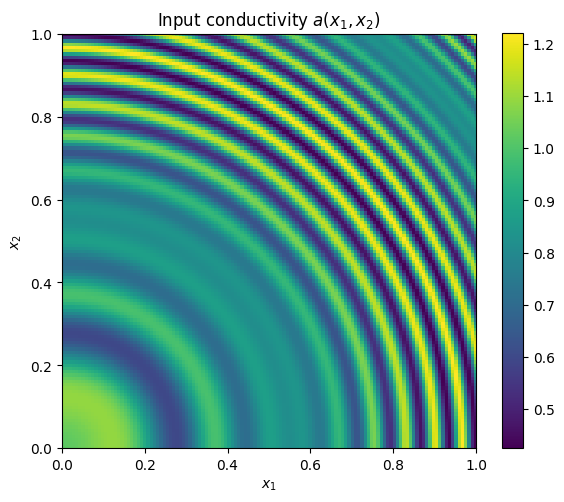

In [32]:
# -----------------------------
# Plot input conductivity a(x,y)
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(a_plot, origin="lower", extent=[0, 1, 0, 1])
plt.colorbar()
plt.title(r"Input conductivity $a(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.tight_layout()
plt.show()

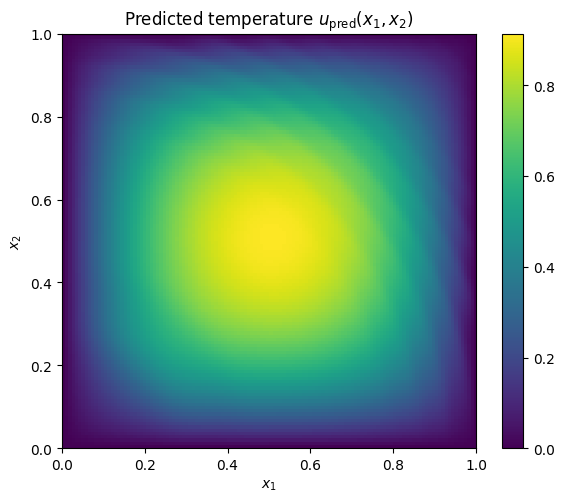

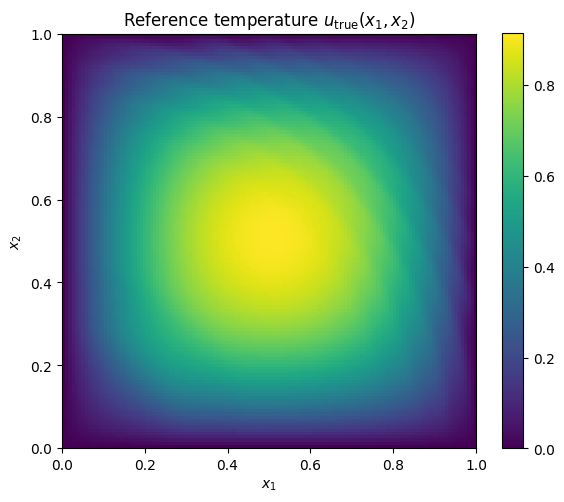

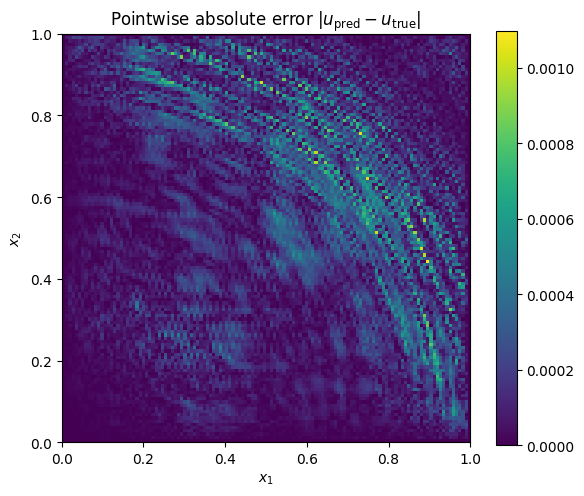

In [33]:
# -----------------------------
# Plot predicted temperature u_pred(x,y)
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(u_pred_plot, origin="lower", extent=[0, 1, 0, 1])
plt.colorbar()
plt.title(r"Predicted temperature $u_{\mathrm{pred}}(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot reference temperature u_true(x,y)
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(u_true_plot, origin="lower", extent=[0, 1, 0, 1])
plt.colorbar()
plt.title(r"Reference temperature $u_{\mathrm{true}}(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.tight_layout()
plt.show()

# -----------------------------
# Pointwise absolute error for u
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(abs_error_plot, origin="lower", extent=[0, 1, 0, 1])
plt.colorbar()
plt.title(r"Pointwise absolute error $|u_{\mathrm{pred}}-u_{\mathrm{true}}|$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.tight_layout()
plt.show()

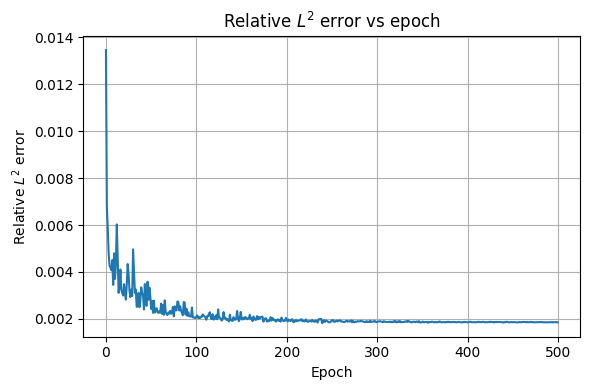

In [34]:
# -----------------------------
# Error vs. epoch
# -----------------------------

plt.figure(figsize=(6, 4))
plt.plot(l2_test_history)
plt.xlabel("Epoch")
plt.ylabel(r"Relative $L^2$ error")
plt.title(r"Relative $L^2$ error vs epoch")
plt.grid(True)
plt.tight_layout()
plt.show()